# Detrex Backend Sanity

This notebook verifies the thin detrex adapter path for the current DAOD dataset.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
sys.path.append('../../')
from types import SimpleNamespace

import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from detectron2.data import MetadataCatalog
from detectron2.utils.visualizer import Visualizer
import detrex

from src.data.daod_cityscapes import build_dataset
from src.models.detrex_adapter import build_daod_model, load_daod_model_config, run_daod_inference

cfg = SimpleNamespace(
    data=SimpleNamespace(
        root="/home/ljzhang/data/ins-seg/cityscapes",
        foggy_beta="0.02",
    ),
    detector=SimpleNamespace(
        model_name="dino_r50_4scale_12ep",
        checkpoint_name="dino_r50_4scale_12ep_49_2AP.pth",
    ),
)

print('detrex import:', detrex.__file__)
print('cuda available:', torch.cuda.is_available())

/local/home/ljzhang/code/SFADA/external/detrex/detrex/layers/dcn_v3.py:23: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/local/home/ljzhang/code/SFADA/external/detrex/detrex/layers/dcn_v3.py:52: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers",

detrex import: /local/home/ljzhang/code/SFADA/external/detrex/detrex/__init__.py
cuda available: True


In [2]:
source_ds = build_dataset(cfg, "source_val", transform=None)
target_ds = build_dataset(cfg, "target_val", transform=None)
len(source_ds), len(target_ds)

(500, 500)

In [3]:
adapter_cfg = load_daod_model_config(cfg)
adapter_cfg

DetrexAdapterConfig(model_name='dino_r50_4scale_12ep', config_path='/local/home/ljzhang/code/SFADA/external/detrex/projects/dino/configs/dino-resnet/dino_r50_4scale_12ep.py', init_checkpoint='/local/home/ljzhang/code/SFADA/external/detrex/ckpts/dino_r50_4scale_12ep_49_2AP.pth', min_size_test=800, max_size_test=1333)

In [5]:
adapter = build_daod_model(cfg, load_weights=True)
type(adapter.model).__name__, adapter.config.init_checkpoint

Retrying checkpoint load with weights_only=False for /local/home/ljzhang/code/SFADA/external/detrex/ckpts/dino_r50_4scale_12ep_49_2AP.pth due to PyTorch 2.6 weights-only deserialization restrictions.


('DINO',
 '/local/home/ljzhang/code/SFADA/external/detrex/ckpts/dino_r50_4scale_12ep_49_2AP.pth')

In [6]:
source_batch = [source_ds[i] for i in range(2)]
target_batch = [target_ds[i] for i in range(2)]
mixed_batch = [source_batch[0], target_batch[0]]

for sample in mixed_batch:
    assert Path(sample["file_name"]).exists()
    assert sample["annotations"] is not None
    assert sample["height"] > 0 and sample["width"] > 0
mixed_batch[0]

{'sample_id': 'source_val:frankfurt:frankfurt_000000_000294',
 'file_name': '/home/ljzhang/data/ins-seg/cityscapes/leftImg8bit/val/frankfurt/frankfurt_000000_000294_leftImg8bit.png',
 'image_id': 'source_val:frankfurt:frankfurt_000000_000294',
 'height': 1024,
 'width': 2048,
 'annotations': [{'bbox': [949.0, 406.0, 965.0, 445.0],
   'bbox_mode': 0,
   'category_id': 0,
   'segmentation': [[960.0,
     444.0,
     960.0,
     439.0,
     960.0,
     430.0,
     961.0,
     428.0,
     964.0,
     428.0,
     965.0,
     425.0,
     965.0,
     421.0,
     962.0,
     418.0,
     959.0,
     415.0,
     958.0,
     411.0,
     957.0,
     409.0,
     955.0,
     406.0,
     955.0,
     406.0,
     954.0,
     406.0,
     951.0,
     408.0,
     949.0,
     413.0,
     949.0,
     419.0,
     951.0,
     430.0,
     952.0,
     433.0,
     952.0,
     435.0,
     954.0,
     440.0,
     954.0,
     442.0,
     954.0,
     443.0,
     955.0,
     445.0,
     959.0,
     445.0]],
   'iscro

In [7]:
outputs = run_daod_inference(adapter, mixed_batch)
assert len(outputs) == len(mixed_batch)
outputs[0].keys()

/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


dict_keys(['sample_id', 'file_name', 'prediction'])

In [8]:
pred = outputs[0]["prediction"]
assert "instances" in pred
instances = pred["instances"].to("cpu")
print(instances)
instances

Instances(num_instances=300, image_height=1024, image_width=2048, fields=[pred_boxes: Boxes(tensor([[1223.5730,  374.8445, 1256.3457,  470.6920],
        [1251.4993,  307.8386, 1767.6492,  566.3276],
        [1020.8011,  375.2052, 1167.8315,  500.6054],
        ...,
        [1172.9601,  392.4793, 1193.1337,  428.6559],
        [1938.5248,  382.2753, 2047.9060,  522.4304],
        [   5.4032,  738.6026, 2020.4226, 1013.3711]])), scores: tensor([0.8475, 0.8387, 0.8156, 0.8045, 0.7942, 0.4005, 0.3150, 0.2903, 0.2633,
        0.2487, 0.2439, 0.2293, 0.2094, 0.1988, 0.1894, 0.1838, 0.1579, 0.1550,
        0.1449, 0.1384, 0.1342, 0.1312, 0.1310, 0.1307, 0.1306, 0.1250, 0.1208,
        0.1197, 0.1184, 0.1171, 0.1167, 0.1118, 0.1106, 0.1100, 0.1095, 0.1078,
        0.1015, 0.1010, 0.0992, 0.0990, 0.0988, 0.0985, 0.0985, 0.0976, 0.0973,
        0.0965, 0.0944, 0.0943, 0.0941, 0.0941, 0.0937, 0.0903, 0.0899, 0.0892,
        0.0882, 0.0864, 0.0863, 0.0862, 0.0847, 0.0846, 0.0845, 0.0836, 0.0833,


Instances(num_instances=300, image_height=1024, image_width=2048, fields=[pred_boxes: Boxes(tensor([[1223.5730,  374.8445, 1256.3457,  470.6920],
        [1251.4993,  307.8386, 1767.6492,  566.3276],
        [1020.8011,  375.2052, 1167.8315,  500.6054],
        ...,
        [1172.9601,  392.4793, 1193.1337,  428.6559],
        [1938.5248,  382.2753, 2047.9060,  522.4304],
        [   5.4032,  738.6026, 2020.4226, 1013.3711]])), scores: tensor([0.8475, 0.8387, 0.8156, 0.8045, 0.7942, 0.4005, 0.3150, 0.2903, 0.2633,
        0.2487, 0.2439, 0.2293, 0.2094, 0.1988, 0.1894, 0.1838, 0.1579, 0.1550,
        0.1449, 0.1384, 0.1342, 0.1312, 0.1310, 0.1307, 0.1306, 0.1250, 0.1208,
        0.1197, 0.1184, 0.1171, 0.1167, 0.1118, 0.1106, 0.1100, 0.1095, 0.1078,
        0.1015, 0.1010, 0.0992, 0.0990, 0.0988, 0.0985, 0.0985, 0.0976, 0.0973,
        0.0965, 0.0944, 0.0943, 0.0941, 0.0941, 0.0937, 0.0903, 0.0899, 0.0892,
        0.0882, 0.0864, 0.0863, 0.0862, 0.0847, 0.0846, 0.0845, 0.0836, 0.0833,


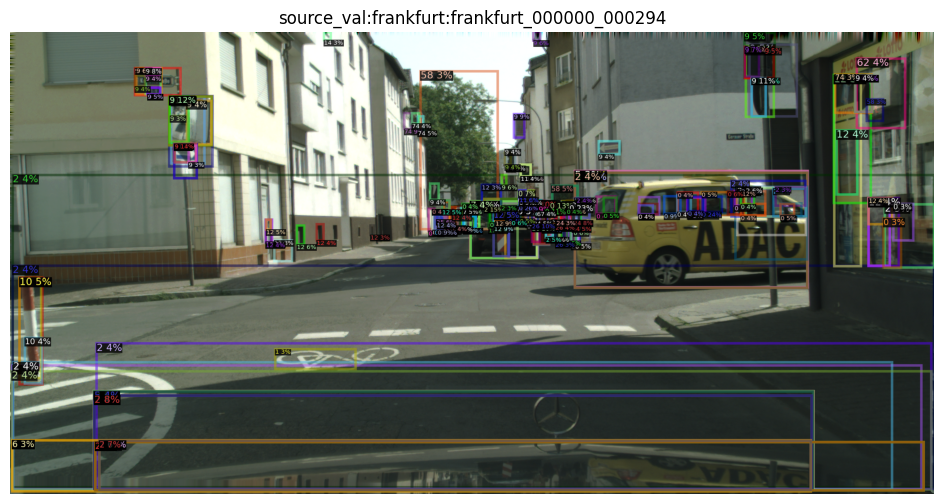

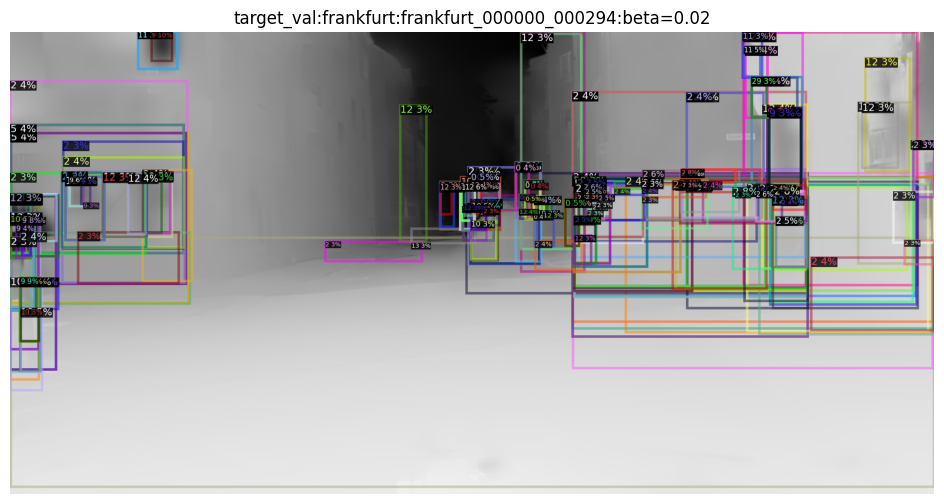

In [9]:
metadata = MetadataCatalog.get("daod_detrex_demo")
metadata.set(thing_classes=[str(i) for i in range(80)])

def visualize_prediction(sample, prediction, title):
    image = np.asarray(Image.open(sample["file_name"]).convert("RGB"))
    vis = Visualizer(image, metadata=metadata)
    rendered = vis.draw_instance_predictions(prediction["instances"].to("cpu")).get_image()
    plt.figure(figsize=(12, 6))
    plt.imshow(rendered)
    plt.title(title)
    plt.axis("off")


for sample, output in zip(mixed_batch, outputs):
    visualize_prediction(sample, output["prediction"], f"{sample['sample_id']}")

In [10]:
source_outputs = run_daod_inference(adapter, source_batch)
target_outputs = run_daod_inference(adapter, target_batch)

print('source sample ids:', [item['sample_id'] for item in source_outputs])
print('target sample ids:', [item['sample_id'] for item in target_outputs])
print('source instances per sample:', [len(item['prediction']['instances']) for item in source_outputs])
print('target instances per sample:', [len(item['prediction']['instances']) for item in target_outputs])

source sample ids: ['source_val:frankfurt:frankfurt_000000_000294', 'source_val:frankfurt:frankfurt_000000_000576']
target sample ids: ['target_val:frankfurt:frankfurt_000000_000294:beta=0.02', 'target_val:frankfurt:frankfurt_000000_000576:beta=0.02']
source instances per sample: [300, 300]
target instances per sample: [300, 300]
